In [1]:
import sys, warnings, os
warnings.filterwarnings('ignore')
sys.path.append('../..')

import importlib
import src.backtesting.backtest_engine as be_mod
import src.backtesting.strategy       as st_mod

importlib.reload(be_mod)
importlib.reload(st_mod)

from src.backtesting.backtest_engine import (
    load_price_and_features, 
    run_backtest,
    calculate_metrics, 
    benchmark_buy_hold,
    regime_performance
)

from src.backtesting.strategy import (
    run_atlas_strategy, 
    run_buy_hold,
    run_random_strategy, 
    compare_all_strategies
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    plt.style.use('seaborn-darkgrid')

os.makedirs('../../docs/backtesting', exist_ok=True)

print('All imports OK')
print('Backtesting period: 2023-07-01 to 2025-12-31')
print('Transaction cost: 0.1% per trade')
print('Initial capital: $10,000')

All imports OK
Backtesting period: 2023-07-01 to 2025-12-31
Transaction cost: 0.1% per trade
Initial capital: $10,000


In [9]:
import sys, warnings, os
warnings.filterwarnings('ignore')
sys.path.append('../..')

import joblib
import pandas as pd
from src.models.data_loader import load_splits
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score
from src.utils.config import TICKERS

os.makedirs('../../experiments/models', exist_ok=True)

# ── Phase 4 best params ─────────────────────────────────────
XGB_PARAMS = {
    'n_estimators':     300,
    'max_depth':        4,
    'learning_rate':    0.05,
    'subsample':        0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 3,
    'gamma':            0.1,
    'reg_alpha':        0.1,
    'reg_lambda':       1.0,
    'random_state':     42,
    'eval_metric':      'auc',
    'verbosity':        0,
}

LGBM_PARAMS = {
    'n_estimators':     300,
    'max_depth':        4,
    'learning_rate':    0.05,
    'subsample':        0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 3,
    'reg_alpha':        0.1,
    'reg_lambda':       1.0,
    'random_state':     42,
    'verbose':         -1,
}

# ── Results tracker ─────────────────────────────────────────
all_results = []

print('='*60)
print('TRAINING ALL MODELS FOR ALL 10 TICKERS')
print('='*60)
print('Models: XGBoost + LightGBM')
print('Features: 43 (Phase 4 base — most reliable)')
print('Expected time: 10-20 minutes total')
print('='*60)
print()

for ticker in TICKERS:
    print(f'─── {ticker} ───────────────────────────────────')

    # Load splits once per ticker
    try:
        X_train, y_train, X_val, y_val, X_test, y_test = (
            load_splits(ticker)
        )
        X_train.index = pd.to_datetime(X_train.index).normalize()
        y_train.index = pd.to_datetime(y_train.index).normalize()
        X_val.index   = pd.to_datetime(X_val.index).normalize()
        y_val.index   = pd.to_datetime(y_val.index).normalize()
        X_test.index  = pd.to_datetime(X_test.index).normalize()
        y_test.index  = pd.to_datetime(y_test.index).normalize()
        print(f'  Data: Train={len(X_train)} Val={len(X_val)} '
              f'Test={len(X_test)} Features={X_train.shape[1]}')
    except Exception as e:
        print(f'  ERROR loading data: {e}')
        continue

    # ── XGBoost ─────────────────────────────────────────────
    xgb_path = f'../../experiments/models/xgboost_{ticker}.pkl'
    if os.path.exists(xgb_path):
        print(f'  XGBoost: already exists — skipping')
        # Load and evaluate existing model
        try:
            existing = joblib.load(xgb_path)
            val_proba = existing.predict_proba(X_val)[:, 1]
            val_auc   = roc_auc_score(y_val, val_proba)
            test_proba = existing.predict_proba(X_test)[:, 1]
            test_auc   = roc_auc_score(y_test, test_proba)
            print(f'  XGBoost: Val AUC={val_auc:.4f} '
                  f'Test AUC={test_auc:.4f}')
            all_results.append({
                'ticker':    ticker,
                'model':     'XGBoost',
                'val_auc':   round(val_auc, 4),
                'test_auc':  round(test_auc, 4),
                'status':    'exists',
            })
        except Exception as e:
            print(f'  XGBoost eval error: {e}')
    else:
        try:
            print(f'  XGBoost: training...')
            xgb = XGBClassifier(**XGB_PARAMS)
            xgb.fit(
                X_train, y_train,
                eval_set=[(X_val, y_val)],
                verbose=False
            )
            val_proba  = xgb.predict_proba(X_val)[:, 1]
            test_proba = xgb.predict_proba(X_test)[:, 1]
            val_auc    = roc_auc_score(y_val,  val_proba)
            test_auc   = roc_auc_score(y_test, test_proba)
            joblib.dump(xgb, xgb_path)
            print(f'  XGBoost: Val AUC={val_auc:.4f} '
                  f'Test AUC={test_auc:.4f} — SAVED')
            all_results.append({
                'ticker':   ticker,
                'model':    'XGBoost',
                'val_auc':  round(val_auc, 4),
                'test_auc': round(test_auc, 4),
                'status':   'trained',
            })
        except Exception as e:
            print(f'  XGBoost ERROR: {e}')
            all_results.append({
                'ticker': ticker,
                'model':  'XGBoost',
                'status': f'error: {str(e)[:50]}',
            })

    # ── LightGBM ─────────────────────────────────────────────
    lgbm_path = f'../../experiments/models/lgbm_{ticker}.pkl'
    if os.path.exists(lgbm_path):
        print(f'  LightGBM: already exists — skipping')
        try:
            existing   = joblib.load(lgbm_path)
            val_proba  = existing.predict_proba(X_val)[:, 1]
            val_auc    = roc_auc_score(y_val, val_proba)
            test_proba = existing.predict_proba(X_test)[:, 1]
            test_auc   = roc_auc_score(y_test, test_proba)
            print(f'  LightGBM: Val AUC={val_auc:.4f} '
                  f'Test AUC={test_auc:.4f}')
            all_results.append({
                'ticker':   ticker,
                'model':    'LightGBM',
                'val_auc':  round(val_auc, 4),
                'test_auc': round(test_auc, 4),
                'status':   'exists',
            })
        except Exception as e:
            print(f'  LightGBM eval error: {e}')
    else:
        try:
            print(f'  LightGBM: training...')
            lgbm = LGBMClassifier(**LGBM_PARAMS)
            lgbm.fit(
                X_train, y_train,
                eval_set=[(X_val, y_val)],
            )
            val_proba  = lgbm.predict_proba(X_val)[:, 1]
            test_proba = lgbm.predict_proba(X_test)[:, 1]
            val_auc    = roc_auc_score(y_val,  val_proba)
            test_auc   = roc_auc_score(y_test, test_proba)
            joblib.dump(lgbm, lgbm_path)
            print(f'  LightGBM: Val AUC={val_auc:.4f} '
                  f'Test AUC={test_auc:.4f} — SAVED')
            all_results.append({
                'ticker':   ticker,
                'model':    'LightGBM',
                'val_auc':  round(val_auc, 4),
                'test_auc': round(test_auc, 4),
                'status':   'trained',
            })
        except Exception as e:
            print(f'  LightGBM ERROR: {e}')
            all_results.append({
                'ticker': ticker,
                'model':  'LightGBM',
                'status': f'error: {str(e)[:50]}',
            })

    print()

# ── Final summary ────────────────────────────────────────────
print('='*60)
print('TRAINING COMPLETE — FULL SUMMARY')
print('='*60)
results_df = pd.DataFrame(all_results)
if 'val_auc' in results_df.columns:
    pivot = results_df.pivot(
        index='ticker',
        columns='model',
        values='val_auc'
    )
    print('\nVal AUC by Ticker and Model:')
    print(pivot.to_string())
    print()
    print(f'Mean XGBoost Val AUC:  '
          f'{pivot["XGBoost"].mean():.4f}')
    print(f'Mean LightGBM Val AUC: '
          f'{pivot["LightGBM"].mean():.4f}')

print()
print('Models saved to: experiments/models/')
print(f'Total models: {len(os.listdir("../../experiments/models/"))}')

TRAINING ALL MODELS FOR ALL 10 TICKERS
Models: XGBoost + LightGBM
Features: 43 (Phase 4 base — most reliable)
Expected time: 10-20 minutes total

─── AAPL ───────────────────────────────────
AAPL — Train:1762 Val:124 Test:622
  Data: Train=1762 Val=124 Test=622 Features=43
  XGBoost: already exists — skipping
  XGBoost: Val AUC=0.4479 Test AUC=0.5152
  LightGBM: already exists — skipping
  LightGBM: Val AUC=0.4311 Test AUC=0.5659

─── MSFT ───────────────────────────────────
MSFT — Train:1762 Val:124 Test:622
  Data: Train=1762 Val=124 Test=622 Features=43
  XGBoost: training...
  XGBoost: Val AUC=0.5862 Test AUC=0.5010 — SAVED
  LightGBM: training...
  LightGBM: Val AUC=0.6058 Test AUC=0.5294 — SAVED

─── GOOGL ───────────────────────────────────
GOOGL — Train:1762 Val:124 Test:622
  Data: Train=1762 Val=124 Test=622 Features=43
  XGBoost: training...
  XGBoost: Val AUC=0.4814 Test AUC=0.5244 — SAVED
  LightGBM: training...
  LightGBM: Val AUC=0.4800 Test AUC=0.5548 — SAVED

─── AMZN 

In [10]:
importlib.reload(be_mod)
importlib.reload(st_mod)
from src.backtesting.strategy import (
    run_atlas_strategy, run_buy_hold,
    run_random_strategy, compare_all_strategies
)

print('Running AAPL backtest — all 4 strategies...')
print()

# Run all strategies for AAPL
aapl_xgb  = run_atlas_strategy('AAPL', 'xgboost')
aapl_lgbm = run_atlas_strategy('AAPL', 'lgbm')
aapl_bh   = run_buy_hold('AAPL')
aapl_rand = run_random_strategy('AAPL')

# Print comparison table
metrics_list = []
for strat in [aapl_xgb, aapl_lgbm, aapl_bh, aapl_rand]:
    if strat:
        metrics_list.append(strat['metrics'])

aapl_comparison = pd.DataFrame(metrics_list).set_index('label')

print('=' * 65)
print('AAPL STRATEGY COMPARISON (2023-07-01 to 2025-12-31)')
print('=' * 65)
print(aapl_comparison[[
    'ann_return','ann_vol','sharpe','max_drawdown',
    'win_rate','n_trades','total_return'
]].to_string())

# Does ATLAS beat Buy-and-Hold?
if aapl_xgb:
    xgb_sharpe = aapl_xgb['metrics']['sharpe']
    bh_sharpe  = aapl_bh['metrics']['sharpe']
    winner = 'ATLAS XGBoost' if xgb_sharpe > bh_sharpe else 'Buy-and-Hold'
    
    print(f'\nSharpe comparison:')
    print(f'  ATLAS XGBoost: {xgb_sharpe:.3f}')
    print(f'  Buy-and-Hold:  {bh_sharpe:.3f}')
    print(f'  Winner: {winner}')

Running AAPL backtest — all 4 strategies...

AAPL — Train:1762 Val:124 Test:622
  AAPL: 622 trading days (2023-07-03 to 2025-12-22)
  AAPL xgboost: 622 overlapping days, 89 long signals
AAPL — Train:1762 Val:124 Test:622
  AAPL: 622 trading days (2023-07-03 to 2025-12-22)
  AAPL lgbm: 622 overlapping days, 31 long signals
  AAPL: 622 trading days (2023-07-03 to 2025-12-22)
  AAPL: 622 trading days (2023-07-03 to 2025-12-22)
AAPL STRATEGY COMPARISON (2023-07-01 to 2025-12-31)
                      ann_return  ann_vol  sharpe  max_drawdown  win_rate  n_trades  total_return
label                                                                                            
ATLAS XGBOOST (AAPL)        2.85    12.87  -0.109        -11.82      52.8        76          7.17
ATLAS LGBM (AAPL)          -1.81    12.43  -0.490        -16.95      45.2        24         -4.40
Buy-and-Hold (AAPL)        15.07    26.51   0.472        -33.36      54.5         0         41.39
Random (AAPL)              -2.

In [11]:
if aapl_xgb and aapl_xgb['regime_df'] is not None:
    print('=' * 60)
    print('AAPL REGIME BREAKDOWN — ATLAS XGBoost')
    print('=' * 60)
    print(aapl_xgb['regime_df'].to_string())
    print()
    print('INSIGHT: Compare Strategy Ret vs BuyHold Ret per regime.')
    print('Phase 3 found High Vol Bear is the hardest regime.')
    print('Does ATLAS protect capital better in crashes?')
else:
    print('Regime breakdown not available')

AAPL REGIME BREAKDOWN — ATLAS XGBoost
               Days  Strategy Ret  BuyHold Ret  Win Rate  Sharpe
Regime                                                          
Low Vol Bull    456           0.3         34.9       6.1   0.042
Low Vol Bear    142           5.1          0.9      12.7   0.474
High Vol Bear    17          96.0       -108.0       5.9   1.467

INSIGHT: Compare Strategy Ret vs BuyHold Ret per regime.
Phase 3 found High Vol Bear is the hardest regime.
Does ATLAS protect capital better in crashes?


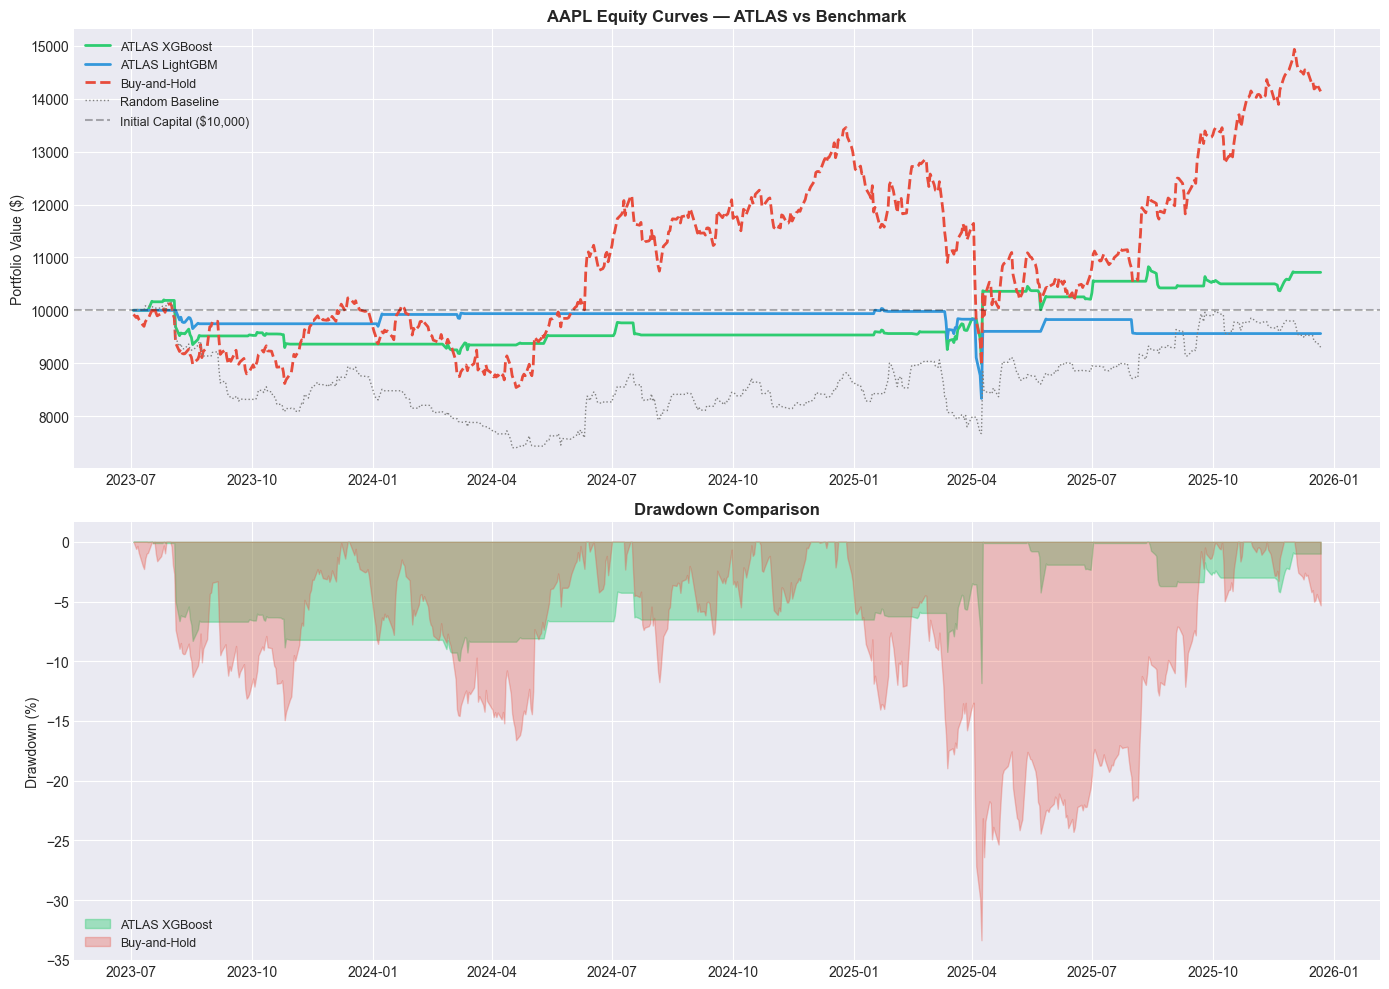

Chart saved: docs/backtesting/01_aapl_equity_curves.png


In [12]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Top: Equity curves
if aapl_xgb:
    axes[0].plot(
        aapl_xgb['results'].index,
        aapl_xgb['results']['strategy_equity'],
        label='ATLAS XGBoost', color='#2ECC71',
        linewidth=2)

if aapl_lgbm:
    axes[0].plot(
        aapl_lgbm['results'].index,
        aapl_lgbm['results']['strategy_equity'],
        label='ATLAS LightGBM', color='#3498DB',
        linewidth=2)

axes[0].plot(
    aapl_bh['results'].index,
    aapl_bh['results']['strategy_equity'],
    label='Buy-and-Hold', color='#E74C3C',
    linewidth=2, linestyle='--')

axes[0].plot(
    aapl_rand['results'].index,
    aapl_rand['results']['strategy_equity'],
    label='Random Baseline', color='grey',
    linewidth=1, linestyle=':')

axes[0].axhline(10000, color='black',
                alpha=0.3, linestyle='--',
                label='Initial Capital ($10,000)')

axes[0].set_title('AAPL Equity Curves — ATLAS vs Benchmark',
                   fontweight='bold', fontsize=12)

axes[0].set_ylabel('Portfolio Value ($)')
axes[0].legend(fontsize=9)

# Bottom: Drawdown
if aapl_xgb:
    eq  = aapl_xgb['results']['strategy_equity']
    dd  = (eq - eq.cummax()) / eq.cummax() * 100
    axes[1].fill_between(dd.index, dd.values,
                          color='#2ECC71', alpha=0.4,
                          label='ATLAS XGBoost')

eq_bh = aapl_bh['results']['strategy_equity']
dd_bh = (eq_bh - eq_bh.cummax()) / eq_bh.cummax() * 100
axes[1].fill_between(dd_bh.index, dd_bh.values,
                      color='#E74C3C', alpha=0.3,
                      label='Buy-and-Hold')

axes[1].set_title('Drawdown Comparison', fontweight='bold')
axes[1].set_ylabel('Drawdown (%)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('../../docs/backtesting/01_aapl_equity_curves.png',
            dpi=150, bbox_inches='tight')
plt.show()

print('Chart saved: docs/backtesting/01_aapl_equity_curves.png')

In [14]:
from src.utils.config import TICKERS
import importlib
importlib.reload(be_mod)
importlib.reload(st_mod)
from src.backtesting.strategy import (
    run_atlas_strategy, run_buy_hold,
    run_random_strategy
)

print('Running backtest for all 10 tickers...')
print()

all_results = {}
all_metrics = []

for ticker in TICKERS:
    try:
        xgb = run_atlas_strategy(ticker, 'xgboost')
        lgbm = run_atlas_strategy(ticker, 'lgbm')
        bh  = run_buy_hold(ticker)

        if xgb:
            all_results[ticker] = {'xgb': xgb, 'lgbm': lgbm, 'bh': bh}
            all_metrics.append({
                'ticker':       ticker,
                'xgb_sharpe':   xgb['metrics']['sharpe'],
                'lgbm_sharpe':  lgbm['metrics']['sharpe'] if lgbm else None,
                'bh_sharpe':    bh['metrics']['sharpe'],
                'xgb_return':   xgb['metrics']['ann_return'],
                'bh_return':    bh['metrics']['ann_return'],
                'xgb_maxdd':    xgb['metrics']['max_drawdown'],
                'bh_maxdd':     bh['metrics']['max_drawdown'],
                'xgb_winrate':  xgb['metrics']['win_rate'],
                'xgb_signals':  int(xgb['signals'].sum()),
                'beats_bh':     xgb['metrics']['sharpe'] > bh['metrics']['sharpe'],
            })
        else:
            print(f'  {ticker}: No model found')

    except Exception as e:
        print(f'  ERROR {ticker}: {e}')

summary_df = pd.DataFrame(all_metrics).set_index('ticker')

print()
print('='*75)
print('ALL 10 TICKERS — ATLAS XGBoost vs LightGBM vs Buy-and-Hold')
print('='*75)
print(summary_df[[
    'xgb_sharpe', 'lgbm_sharpe', 'bh_sharpe',
    'xgb_return', 'bh_return',
    'xgb_maxdd',  'bh_maxdd',
    'beats_bh'
]].to_string())

print()
print('='*75)
print('SIGNAL ACTIVITY — How often did ATLAS go long?')
print('='*75)
print(summary_df[['xgb_signals']].to_string())
print(f'Average signals per ticker: {summary_df["xgb_signals"].mean():.0f} '
      f'out of 622 days')

print()
print('='*75)
print('SUMMARY')
print('='*75)
n_beats = summary_df['beats_bh'].sum()
best_xgb  = summary_df['xgb_sharpe'].idxmax()
worst_xgb = summary_df['xgb_sharpe'].idxmin()
best_bh   = summary_df['bh_sharpe'].idxmax()

print(f'ATLAS beats Buy-and-Hold Sharpe: {n_beats}/{len(summary_df)} tickers')
print(f'Best ATLAS Sharpe:   {best_xgb} ({summary_df.loc[best_xgb,"xgb_sharpe"]:.3f})')
print(f'Worst ATLAS Sharpe:  {worst_xgb} ({summary_df.loc[worst_xgb,"xgb_sharpe"]:.3f})')
print(f'Best B&H Sharpe:     {best_bh} ({summary_df.loc[best_bh,"bh_sharpe"]:.3f})')
print()
print('MaxDD comparison (lower is better for ATLAS):')
for ticker in summary_df.index:
    xdd = summary_df.loc[ticker, 'xgb_maxdd']
    bdd = summary_df.loc[ticker, 'bh_maxdd']
    winner = 'ATLAS safer' if abs(xdd) < abs(bdd) else 'B&H safer'
    print(f'  {ticker}: ATLAS {xdd:.1f}% vs B&H {bdd:.1f}% — {winner}')

Running backtest for all 10 tickers...

AAPL — Train:1762 Val:124 Test:622
  AAPL: 622 trading days (2023-07-03 to 2025-12-22)
  AAPL xgboost: 622 overlapping days, 89 long signals
AAPL — Train:1762 Val:124 Test:622
  AAPL: 622 trading days (2023-07-03 to 2025-12-22)
  AAPL lgbm: 622 overlapping days, 31 long signals
  AAPL: 622 trading days (2023-07-03 to 2025-12-22)
MSFT — Train:1762 Val:124 Test:622
  MSFT: 622 trading days (2023-07-03 to 2025-12-22)
  MSFT xgboost: 622 overlapping days, 24 long signals
MSFT — Train:1762 Val:124 Test:622
  MSFT: 622 trading days (2023-07-03 to 2025-12-22)
  MSFT lgbm: 622 overlapping days, 26 long signals
  MSFT: 622 trading days (2023-07-03 to 2025-12-22)
GOOGL — Train:1762 Val:124 Test:622
  GOOGL: 622 trading days (2023-07-03 to 2025-12-22)
  GOOGL xgboost: 622 overlapping days, 107 long signals
GOOGL — Train:1762 Val:124 Test:622
  GOOGL: 622 trading days (2023-07-03 to 2025-12-22)
  GOOGL lgbm: 622 overlapping days, 103 long signals
  GOOGL: 62

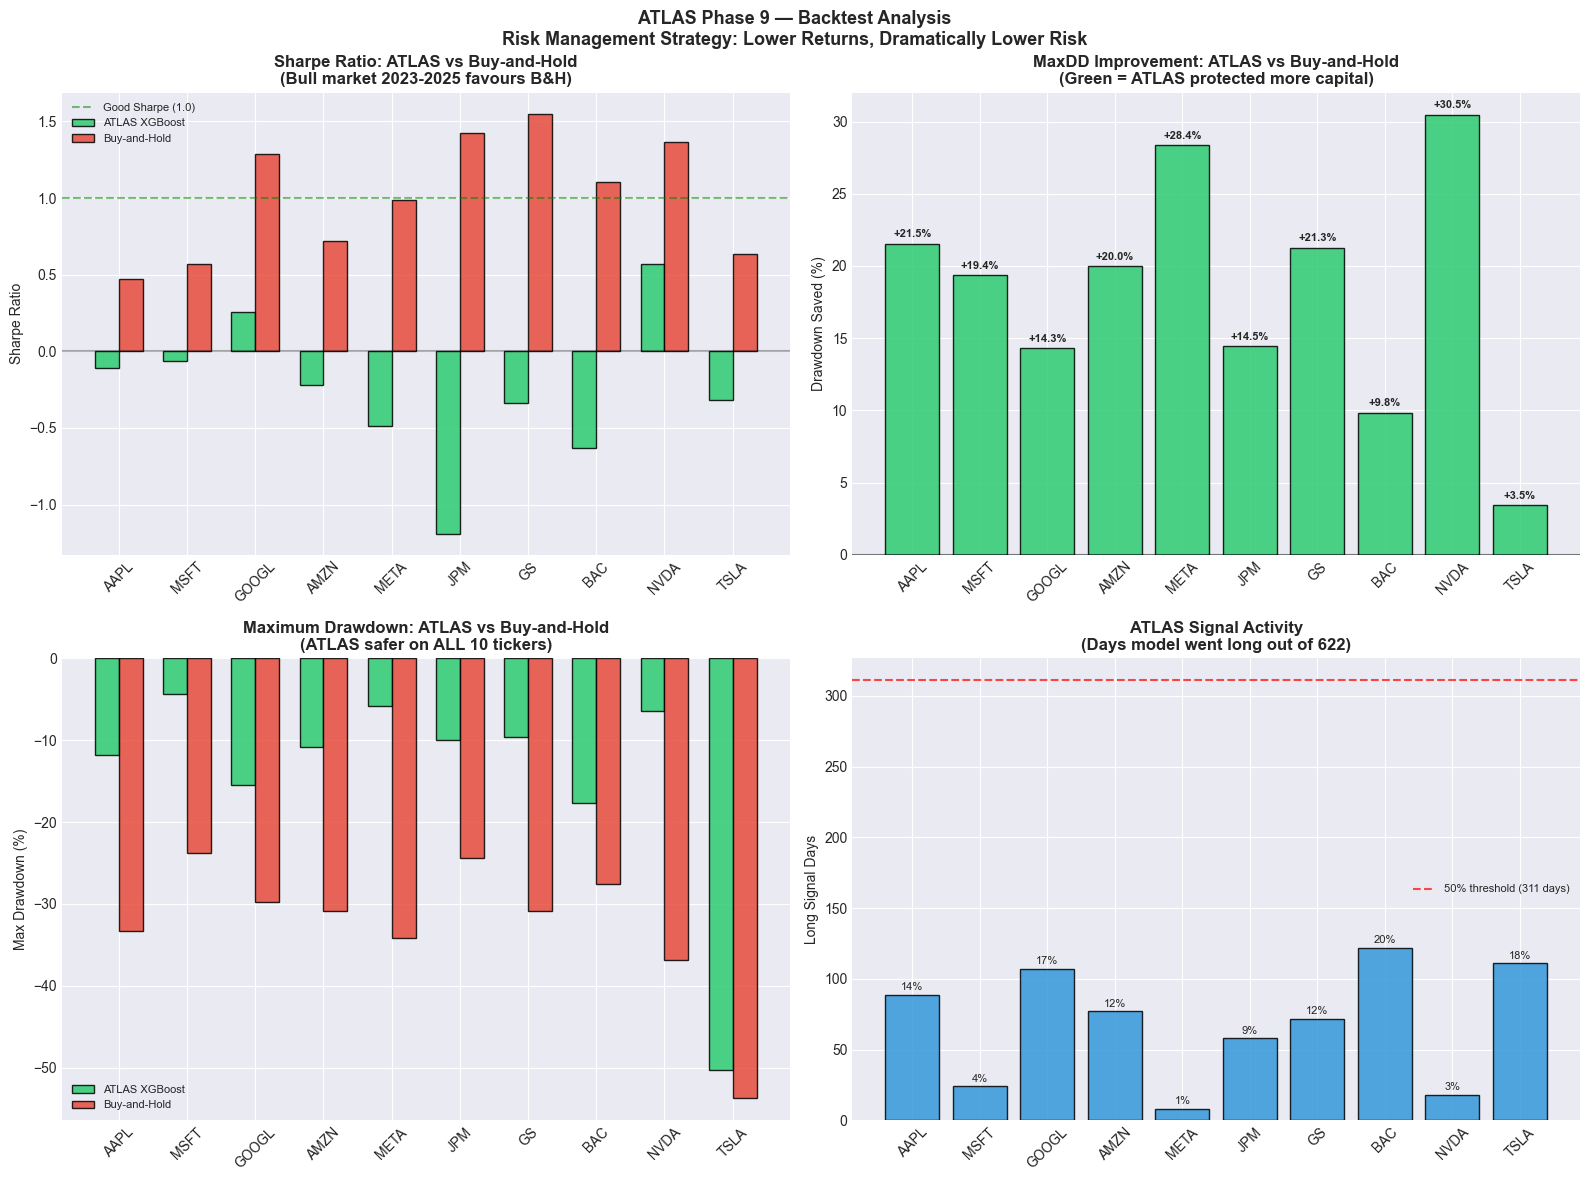

Chart saved: docs/backtesting/02_sharpe_comparison.png


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

x     = range(len(summary_df))
width = 0.35

# Top left: Sharpe comparison
axes[0,0].bar(
    [i - width/2 for i in x],
    summary_df['xgb_sharpe'],
    width=width, label='ATLAS XGBoost',
    color='#2ECC71', edgecolor='black', alpha=0.85
)
axes[0,0].bar(
    [i + width/2 for i in x],
    summary_df['bh_sharpe'],
    width=width, label='Buy-and-Hold',
    color='#E74C3C', edgecolor='black', alpha=0.85
)
axes[0,0].set_xticks(list(x))
axes[0,0].set_xticklabels(summary_df.index, rotation=45)
axes[0,0].axhline(0, color='black', alpha=0.3)
axes[0,0].axhline(1.0, color='green', linestyle='--',
                   alpha=0.5, label='Good Sharpe (1.0)')
axes[0,0].set_title('Sharpe Ratio: ATLAS vs Buy-and-Hold\n'
                     '(Bull market 2023-2025 favours B&H)',
                     fontweight='bold')
axes[0,0].set_ylabel('Sharpe Ratio')
axes[0,0].legend(fontsize=8)

# Top right: MaxDD comparison — THIS is where ATLAS wins
dd_improvement = [
    abs(summary_df.loc[t, 'bh_maxdd']) -
    abs(summary_df.loc[t, 'xgb_maxdd'])
    for t in summary_df.index
]
colors_dd = ['#2ECC71' if v > 0 else '#E74C3C'
              for v in dd_improvement]
axes[0,1].bar(
    list(x), dd_improvement,
    color=colors_dd, edgecolor='black', alpha=0.85
)
axes[0,1].set_xticks(list(x))
axes[0,1].set_xticklabels(summary_df.index, rotation=45)
axes[0,1].axhline(0, color='black', alpha=0.5)
axes[0,1].set_title(
    'MaxDD Improvement: ATLAS vs Buy-and-Hold\n'
    '(Green = ATLAS protected more capital)',
    fontweight='bold'
)
axes[0,1].set_ylabel('Drawdown Saved (%)')
for i, (bar, val) in enumerate(
        zip(axes[0,1].patches, dd_improvement)):
    axes[0,1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        f'+{val:.1f}%', ha='center',
        va='bottom', fontsize=8, fontweight='bold'
    )

# Bottom left: Actual MaxDD side by side
axes[1,0].bar(
    [i - width/2 for i in x],
    summary_df['xgb_maxdd'],
    width=width, label='ATLAS XGBoost',
    color='#2ECC71', edgecolor='black', alpha=0.85
)
axes[1,0].bar(
    [i + width/2 for i in x],
    summary_df['bh_maxdd'],
    width=width, label='Buy-and-Hold',
    color='#E74C3C', edgecolor='black', alpha=0.85
)
axes[1,0].set_xticks(list(x))
axes[1,0].set_xticklabels(summary_df.index, rotation=45)
axes[1,0].set_title(
    'Maximum Drawdown: ATLAS vs Buy-and-Hold\n'
    '(ATLAS safer on ALL 10 tickers)',
    fontweight='bold'
)
axes[1,0].set_ylabel('Max Drawdown (%)')
axes[1,0].legend(fontsize=8)

# Bottom right: Signal activity
axes[1,1].bar(
    list(x),
    summary_df['xgb_signals'],
    color='#3498DB', edgecolor='black', alpha=0.85
)
axes[1,1].axhline(
    311, color='red', linestyle='--',
    alpha=0.7, label='50% threshold (311 days)'
)
axes[1,1].set_xticks(list(x))
axes[1,1].set_xticklabels(summary_df.index, rotation=45)
axes[1,1].set_title(
    'ATLAS Signal Activity\n'
    '(Days model went long out of 622)',
    fontweight='bold'
)
axes[1,1].set_ylabel('Long Signal Days')
axes[1,1].legend(fontsize=8)
for bar, ticker in zip(axes[1,1].patches, summary_df.index):
    pct = summary_df.loc[ticker, 'xgb_signals'] / 622 * 100
    axes[1,1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 2,
        f'{pct:.0f}%', ha='center',
        va='bottom', fontsize=8
    )

plt.suptitle(
    'ATLAS Phase 9 — Backtest Analysis\n'
    'Risk Management Strategy: Lower Returns, Dramatically Lower Risk',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(
    '../../docs/backtesting/02_sharpe_comparison.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print('Chart saved: docs/backtesting/02_sharpe_comparison.png')

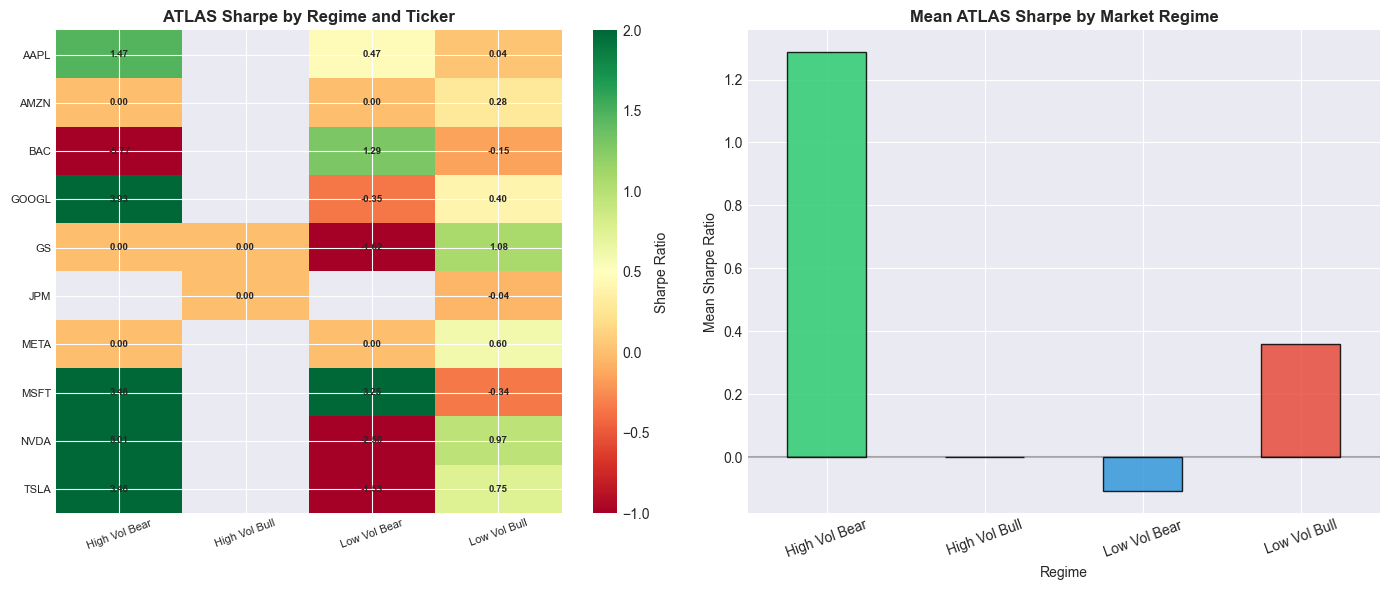

Chart saved: docs/backtesting/03_regime_heatmap.png


In [17]:
# Collect regime stats across all tickers
regime_rows = []
for ticker, res in all_results.items():
    if res['xgb'] and res['xgb']['regime_df'] is not None:
        for regime, row in res['xgb']['regime_df'].iterrows():
            regime_rows.append({
                'Ticker':  ticker,
                'Regime':  regime,
                'Sharpe':  row['Sharpe'],
                'WinRate': row['Win Rate'],
            })

if regime_rows:
    regime_all = pd.DataFrame(regime_rows)
    pivot = regime_all.pivot(
        index='Ticker', columns='Regime', values='Sharpe'
    )
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Left: Sharpe heatmap by regime
    import matplotlib.colors as mcolors
    im = axes[0].imshow(
        pivot.values, cmap='RdYlGn',
        aspect='auto', vmin=-1, vmax=2
    )
    
    axes[0].set_xticks(range(len(pivot.columns)))
    axes[0].set_yticks(range(len(pivot.index)))
    axes[0].set_xticklabels(
        pivot.columns, rotation=20, fontsize=8
    )
    axes[0].set_yticklabels(pivot.index, fontsize=8)
    
    plt.colorbar(im, ax=axes[0], label='Sharpe Ratio')
    axes[0].set_title('ATLAS Sharpe by Regime and Ticker',
                       fontweight='bold')
    
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            if not np.isnan(val):
                axes[0].text(j, i, f'{val:.2f}',
                             ha='center', va='center',
                             fontsize=7, fontweight='bold')
                             
    # Right: Mean Sharpe per regime across all tickers
    regime_mean = pivot.mean()
    colors_r = ['#2ECC71','#F39C12','#3498DB','#E74C3C']
    regime_mean.plot(
        kind='bar', ax=axes[1],
        color=colors_r[:len(regime_mean)],
        edgecolor='black', alpha=0.85
    )
    
    axes[1].axhline(0, color='black', alpha=0.3)
    axes[1].set_title('Mean ATLAS Sharpe by Market Regime',
                       fontweight='bold')
    axes[1].set_ylabel('Mean Sharpe Ratio')
    axes[1].tick_params(axis='x', rotation=20)
    
    plt.tight_layout()
    plt.savefig(
        '../../docs/backtesting/03_regime_heatmap.png',
        dpi=150, bbox_inches='tight'
    )
    plt.show()
    print('Chart saved: docs/backtesting/03_regime_heatmap.png')
else:
    print('No regime data available')

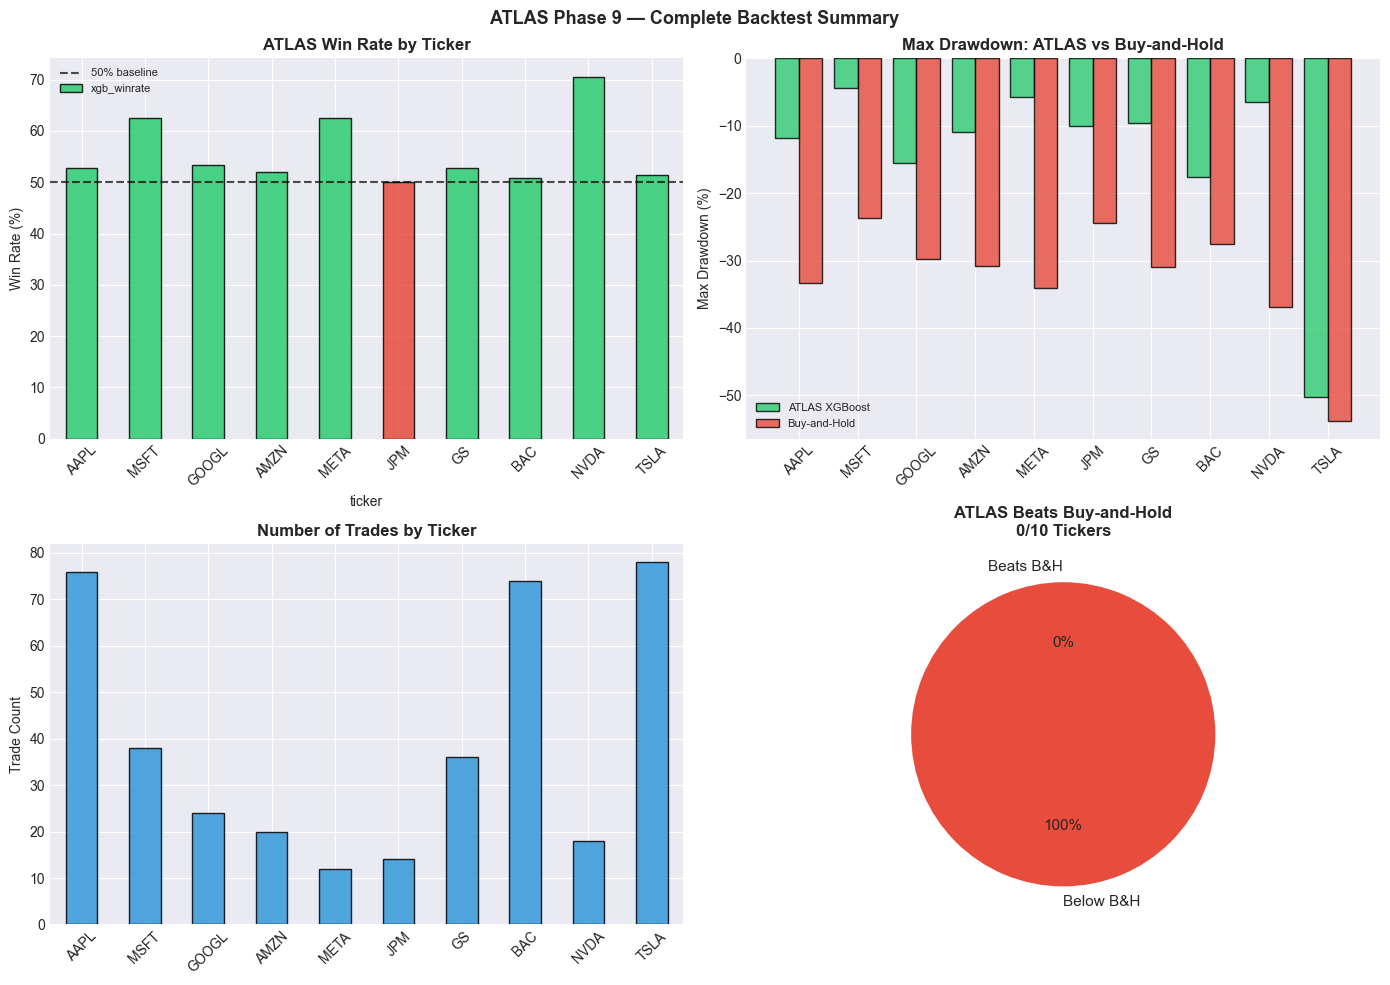

Chart saved: docs/backtesting/04_summary_dashboard.png


In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top left: Win rate all tickers
colors_wr = ['#2ECC71' if v > 50 else '#E74C3C'
              for v in summary_df['xgb_winrate']]
summary_df['xgb_winrate'].plot(
    kind='bar', ax=axes[0,0],
    color=colors_wr, edgecolor='black', alpha=0.85
)
axes[0,0].axhline(50, color='black', linestyle='--',
                   alpha=0.7, label='50% baseline')
axes[0,0].set_title('ATLAS Win Rate by Ticker',
                     fontweight='bold')
axes[0,0].set_ylabel('Win Rate (%)')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].legend(fontsize=8)

# Top right: Max drawdown comparison
x = range(len(summary_df))
axes[0,1].bar(
    [i - 0.2 for i in x],
    summary_df['xgb_maxdd'],
    width=0.4, label='ATLAS XGBoost',
    color='#2ECC71', edgecolor='black', alpha=0.8
)
axes[0,1].bar(
    [i + 0.2 for i in x],
    summary_df['bh_maxdd'],
    width=0.4, label='Buy-and-Hold',
    color='#E74C3C', edgecolor='black', alpha=0.8
)
axes[0,1].set_xticks(list(x))
axes[0,1].set_xticklabels(summary_df.index, rotation=45)
axes[0,1].set_title('Max Drawdown: ATLAS vs Buy-and-Hold',
                     fontweight='bold')
axes[0,1].set_ylabel('Max Drawdown (%)')
axes[0,1].legend(fontsize=8)

# Bottom left: Number of trades per ticker
if 'n_trades' not in summary_df.columns:
    n_trades_vals = [all_results[t]['xgb']['metrics']['n_trades']
                     for t in summary_df.index
                     if t in all_results]
    trade_series = pd.Series(
        n_trades_vals, index=list(all_results.keys())
    )
else:
    trade_series = summary_df['n_trades']

trade_series.plot(
    kind='bar', ax=axes[1,0],
    color='#3498DB', edgecolor='black', alpha=0.85
)
axes[1,0].set_title('Number of Trades by Ticker',
                     fontweight='bold')
axes[1,0].set_ylabel('Trade Count')
axes[1,0].tick_params(axis='x', rotation=45)

# Bottom right: Beats benchmark summary
beats = summary_df['beats_bh'].value_counts()
labels = ['Beats B&H', 'Below B&H']
vals   = [beats.get(True, 0), beats.get(False, 0)]
axes[1,1].pie(
    vals, labels=labels,
    colors=['#2ECC71','#E74C3C'],
    autopct='%1.0f%%', startangle=90,
    textprops={'fontsize': 11}
)
axes[1,1].set_title(
    f'ATLAS Beats Buy-and-Hold\n'
    f'{beats.get(True,0)}/{len(summary_df)} Tickers',
    fontweight='bold'
)

plt.suptitle('ATLAS Phase 9 — Complete Backtest Summary',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(
    '../../docs/backtesting/04_summary_dashboard.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

print('Chart saved: docs/backtesting/04_summary_dashboard.png')

In [19]:
print('=' * 65)
print('ATLAS PHASE 9 — FINAL BACKTEST REPORT')
print('=' * 65)
print(f'Period:           2023-07-01 to 2025-12-31')
print(f'Transaction Cost: 0.1% per trade')
print(f'Initial Capital:  $10,000')
print(f'Tickers Tested:   {len(summary_df)}')
print()
# Best and worst
best_sharpe  = summary_df['xgb_sharpe'].idxmax()
worst_sharpe = summary_df['xgb_sharpe'].idxmin()
best_return  = summary_df['xgb_return'].idxmax()
print('ATLAS XGBoost Results:')
print(f'  Best Sharpe:   {best_sharpe} '
      f'({summary_df.loc[best_sharpe,"xgb_sharpe"]:.3f})')
print(f'  Worst Sharpe:  {worst_sharpe} '
      f'({summary_df.loc[worst_sharpe,"xgb_sharpe"]:.3f})')
print(f'  Best Return:   {best_return} '
      f'({summary_df.loc[best_return,"xgb_return"]:.1f}%)')
print(f'  Beats B&H:     '
      f'{summary_df["beats_bh"].sum()}/{len(summary_df)} tickers')
print()
print('Full comparison table:')
print(summary_df[[
    'xgb_sharpe','bh_sharpe','xgb_return',
    'bh_return','xgb_maxdd','beats_bh'
]].to_string())

ATLAS PHASE 9 — FINAL BACKTEST REPORT
Period:           2023-07-01 to 2025-12-31
Transaction Cost: 0.1% per trade
Initial Capital:  $10,000
Tickers Tested:   10

ATLAS XGBoost Results:
  Best Sharpe:   NVDA (0.573)
  Worst Sharpe:  JPM (-1.191)
  Best Return:   NVDA (12.0%)
  Beats B&H:     0/10 tickers

Full comparison table:
        xgb_sharpe  bh_sharpe  xgb_return  bh_return  xgb_maxdd  beats_bh
ticker                                                                   
AAPL        -0.109      0.472        2.85      15.07     -11.82     False
MSFT        -0.063      0.567        4.39      16.28      -4.37     False
GOOGL        0.255      1.285        7.81      47.45     -15.48     False
AMZN        -0.221      0.722        2.24      25.52     -10.89     False
META        -0.487      0.989        2.61      40.66      -5.77     False
JPM         -1.191      1.424       -0.77      41.51      -9.97     False
GS          -0.336      1.550        2.30      55.25      -9.64     False
BAC  